In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

from scipy.spatial import procrustes

import umap
import polars as pl
import pandas as pd

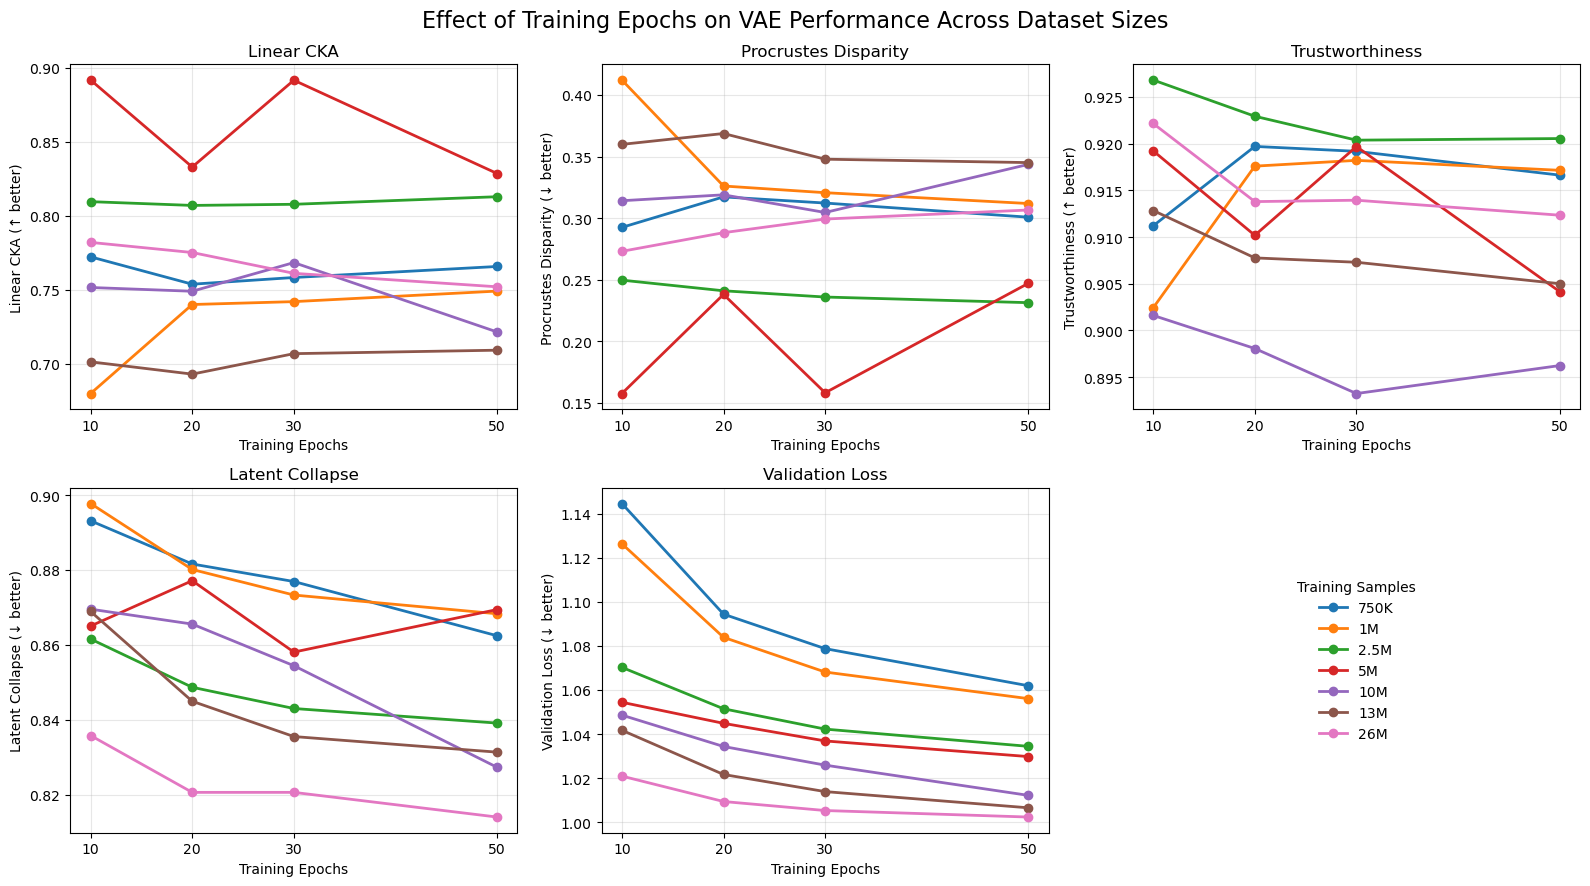

In [16]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load results
with open(r"C:\Users\Owner\Documents\PURE Files\VAE_Stability_Testing\epoch_sweep\vs_52M_results.json", "r") as f:
    df = pd.DataFrame(json.load(f))

# Sort for plotting
df = df.sort_values(["rows", "epochs"])

# Labels for legend
def row_label(rows):
    return f"{rows/1e6:g}M" if rows >= 1_000_000 else "750K"

metrics = [
    ("linear_cka", "Linear CKA", True),
    ("procrustes_disparity", "Procrustes Disparity", False),
    ("trustworthiness", "Trustworthiness", True),
    ("latent_collapse", "Latent Collapse", False),
    ("val_total_loss", "Validation Loss", False),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (metric, title, higher_better) in zip(axes, metrics):

    for rows, group in df.groupby("rows"):

        group = group.sort_values("epochs")

        ax.plot(
            group["epochs"],
            group[metric],
            marker="o",
            linewidth=2,
            label=row_label(rows),
        )

    ax.set_title(title)
    ax.set_xlabel("Training Epochs")
    ax.set_xticks([10, 20, 30, 50])
    ax.grid(alpha=0.3)

    if higher_better:
        ax.set_ylabel(f"{title} (↑ better)")
    else:
        ax.set_ylabel(f"{title} (↓ better)")

# Legend occupies last subplot
handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(
    handles,
    labels,
    title="Training Samples",
    loc="center",
    frameon=False,
)
axes[-1].axis("off")

plt.suptitle(
    "Effect of Training Epochs on VAE Performance Across Dataset Sizes",
    fontsize=16,
)
plt.tight_layout()
plt.show()

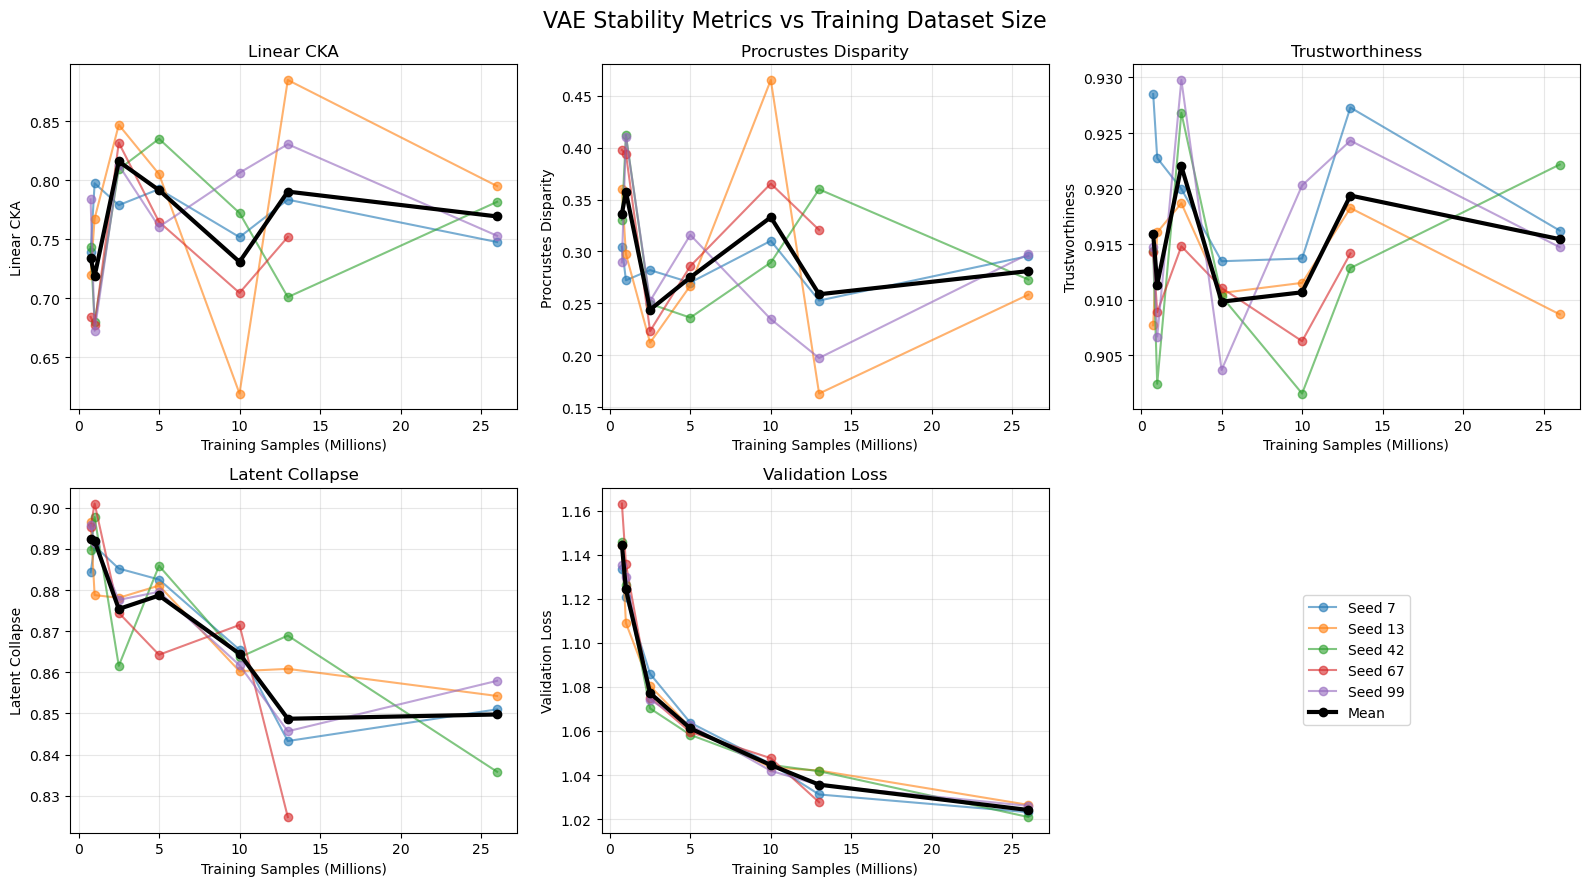

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Load results
# ----------------------------
with open(r"C:\Users\Owner\Documents\PURE Files\VAE_Stability_Testing\seed_sweep_extended\vs_52M_results.json", "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# Convert rows to millions for cleaner axis labels
df["Rows (Millions)"] = df["rows"] / 1e6

metrics = [
    ("linear_cka", "Linear CKA", True),
    ("procrustes_disparity", "Procrustes Disparity", False),
    ("trustworthiness", "Trustworthiness", True),
    ("latent_collapse", "Latent Collapse", False),
    ("val_total_loss", "Validation Loss", False),
]

# ----------------------------
# Plot
# ----------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (metric, title, higher_is_better) in zip(axes, metrics):

    # Plot each seed
    for seed, group in df.groupby("data_seed"):
        group = group.sort_values("Rows (Millions)")
        ax.plot(
            group["Rows (Millions)"],
            group[metric],
            marker="o",
            linewidth=1.5,
            alpha=0.6,
            label=f"Seed {seed}"
        )

    # Mean trend
    mean = (
        df.groupby("Rows (Millions)")[metric]
        .mean()
        .reset_index()
        .sort_values("Rows (Millions)")
    )

    ax.plot(
        mean["Rows (Millions)"],
        mean[metric],
        color="black",
        linewidth=3,
        marker="o",
        label="Mean"
    )

    ax.set_title(title)
    ax.set_xlabel("Training Samples (Millions)")
    ax.set_ylabel(title)
    ax.grid(alpha=0.3)

# Legend only once
handles, labels = axes[0].get_legend_handles_labels()
axes[5].legend(handles, labels, loc="center")
axes[5].axis("off")

plt.suptitle("VAE Stability Metrics vs Training Dataset Size", fontsize=16)
plt.tight_layout()
plt.show()

In [19]:
data = pd.read_parquet(r'C:\Users\Owner\Documents\PURE Files\uv_vae\artifacts\train_then_cluster_20260709T140251Z\clustering\umap_fit_sample.parquet')

In [21]:
data

,row_index,latent_0,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,latent_11,latent_12,latent_13,latent_14,latent_15
0,15,0.165522,-0.698152,-0.239786,0.382325,-0.139525,1.168513,-0.105260,-0.435450,0.052183,-0.228992,0.327695,0.504020,-0.156799,0.126854,0.088741,-0.596349
1,19,0.255387,-0.765259,-0.330173,0.495547,-0.197415,1.304661,-0.162118,-0.473018,0.103770,-0.262814,0.357931,0.702596,-0.223203,0.144890,0.069092,-0.703954
2,21,0.170473,-0.699448,-0.257030,0.423279,-0.125813,1.171266,-0.140455,-0.466596,0.084423,-0.218751,0.331255,0.504893,-0.161302,0.098805,0.072042,-0.658706
3,38,0.067217,-0.668906,0.105225,0.301079,-0.286969,0.589703,-0.003435,-0.312853,-0.008790,0.140799,0.322412,0.150253,0.002132,0.011623,0.296010,-0.382878
4,39,0.056701,-0.624634,0.097694,0.288518,-0.230827,0.577910,0.006508,-0.305233,0.040321,0.090585,0.370857,0.233326,-0.053424,0.023824,0.275937,-0.346310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,999965,0.172611,-0.688188,-0.189410,0.473672,-0.198423,0.918737,-0.332713,-0.465092,-0.006752,0.030403,0.156851,0.521729,-0.213547,0.085713,-0.005320,-0.464789
99996,999978,0.223019,-0.684993,-0.188691,0.438187,-0.144902,0.906236,-0.277853,-0.395114,0.015200,-0.086366,0.284765,0.526336,-0.238380,0.046933,0.045442,-0.510809
99997,999987,0.219276,-0.668529,-0.212018,0.468065,-0.103041,0.989419,-0.240141,-0.399321,0.048238,-0.117202,0.292342,0.524466,-0.253918,0.038823,0.049050,-0.559384
99998,999990,0.180274,-0.689734,-0.201359,0.474556,-0.188143,0.953212,-0.329611,-0.455639,0.000364,-0.006306,0.181684,0.539191,-0.236694,0.086521,-0.010986,-0.472510


In [10]:
digits = load_digits()

X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
reference_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

reference_model.fit(X_train)

reference_embedding = reference_model.transform(X_test)

c:\Users\Owner\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [12]:
rng = np.random.default_rng(42)

sample_sizes = [1.0, 0.9, 0.75, 0.5, 0.25]

disparities = []

for frac in sample_sizes:

    n = int(frac * len(X_train))

    idx = rng.choice(len(X_train), n, replace=False)

    X_subset = X_train[idx]

    model = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        random_state=42
    )

    model.fit(X_subset)

    test_embedding = model.transform(X_test)

    _, _, disparity = procrustes(
        reference_embedding,
        test_embedding
    )

    disparities.append(disparity)

    print(f"{frac:.0%} training -> disparity = {disparity:.4f}")

c:\Users\Owner\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


100% training -> disparity = 0.1534


c:\Users\Owner\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


90% training -> disparity = 0.2028


c:\Users\Owner\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


75% training -> disparity = 0.3452


c:\Users\Owner\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


50% training -> disparity = 0.2033


c:\Users\Owner\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


25% training -> disparity = 0.6719


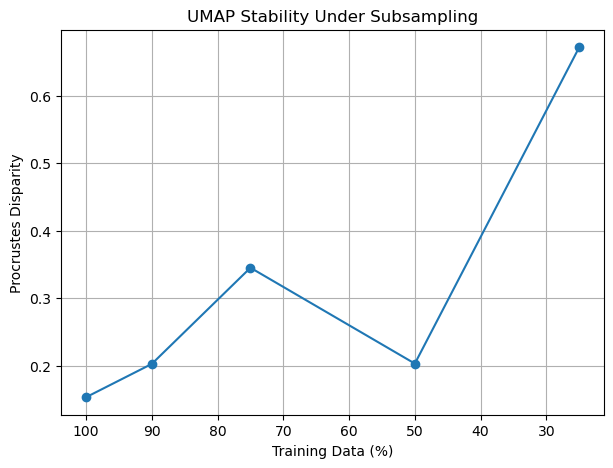

In [13]:
plt.figure(figsize=(7,5))

plt.plot(
    np.array(sample_sizes) * 100,
    disparities,
    marker="o"
)

plt.gca().invert_xaxis()

plt.xlabel("Training Data (%)")
plt.ylabel("Procrustes Disparity")
plt.title("UMAP Stability Under Subsampling")

plt.grid(True)

plt.show()